In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy.stats import f 

import warnings
warnings.filterwarnings('ignore')

In [7]:
from sklearn.datasets import load_wine
wine = load_wine(as_frame=True)
df = wine.frame

In [8]:
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [9]:
df['target'].unique()

array([0, 1, 2])

In [10]:
df01 = df[df['target'].isin([0,1])]

<Axes: xlabel='target', ylabel='alcohol'>

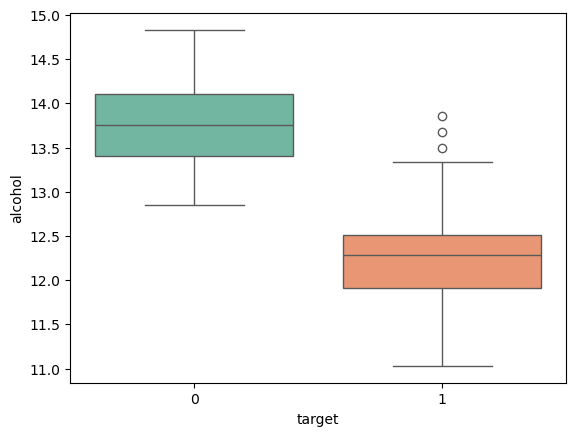

In [13]:
sns.boxplot(x = 'target', y = 'alcohol', data = df01, palette = 'Set2')

In [14]:
a0 = df[df['target'] == 0]['alcohol']
a1 = df[df['target'] == 1]['alcohol']

In [15]:
from scipy.stats import shapiro, levene

shapiro(a0)

ShapiroResult(statistic=0.9808939732940862, pvalue=0.47906805750231335)

In [16]:
shapiro(a1)

ShapiroResult(statistic=0.9720515958359174, pvalue=0.11396072209600777)

In [17]:
import numpy as np 

In [18]:
var0 = np.var(a0, ddof = 1)
var1 = np.var(a1, ddof = 1)
print(var0)
print(var1)

0.21355984804208064
0.28940551307847084


In [19]:
F = var1 / var0

In [20]:
df0 = len(a0) - 1
df1 = len(a1) - 1

In [21]:
p_val = 1 - f.cdf(F, df1, df0)

In [22]:
p_val   # p-value > 0.05 --> H0 기각하지 못함 --> 통계적으로 분산이 유의미하게 다르지 않다.

0.11706942746335502

In [26]:
df = pd.read_csv('paired_ttest.csv')
df.head()

,subject,age,gender,group,score_before,score_after
0,1,22,Female,Control,72.602923,76.621921
1,2,48,Male,Control,62.157335,65.288799
2,3,54,Male,Control,50.098954,49.453684
3,4,58,Male,Control,72.295027,74.936191
4,5,37,Female,Treatment,71.925477,79.723112


In [27]:
before = df[df['group'] == 'Treatment']['score_before']
after = df[df['group'] == 'Treatment']['score_after']

In [28]:
shapiro(before)

ShapiroResult(statistic=0.990387761838582, pvalue=0.365685031062183)

In [29]:
shapiro(after)

ShapiroResult(statistic=0.9913115314746922, pvalue=0.4547402923622468)

In [30]:
var_before = np.var(before, ddof = 1)
var_after = np.var(after, ddof = 1)

In [31]:
print(var_before)
print(var_after)

40.397843909443736
43.37458412312039


In [32]:
df_b = len(before) -1
df_a = len(after) -1

In [33]:
F = var_after / var_before

In [34]:
p_val = 1 - f.cdf(F, df_a, df_b)

In [35]:
p_val # 분산에 차이가 없음

0.3287944361405539

In [36]:
iris = sns.load_dataset('iris')
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [37]:
iris['species'].unique()

array(['setosa', 'versicolor', 'virginica'], dtype=object)

<Axes: xlabel='species', ylabel='sepal_length'>

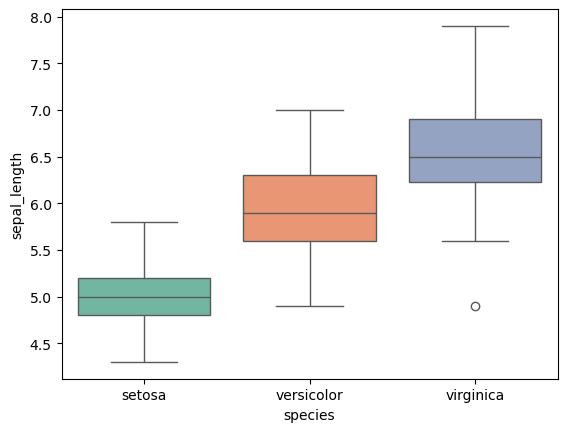

In [38]:
sns.boxplot(x = 'species', y = 'sepal_length', data=iris, palette='Set2')

In [39]:
setosa = iris[iris['species'] == 'setosa']['sepal_length']
versicolor = iris[iris['species'] == 'versicolor']['sepal_length']
virginica = iris[iris['species'] == 'virginica']['sepal_length']

In [40]:
# H0: setosa, versicolor, virginica의 sepal length 평균이 같다.
# H1: setosa, versicolor, virginica의 sepal length 평균이 적어도 하나는 다르다.

In [41]:
print(shapiro(setosa))
print(shapiro(versicolor))
print(shapiro(virginica))  # 정규성 만족

ShapiroResult(statistic=0.977698549796646, pvalue=0.4595131499174534)
ShapiroResult(statistic=0.9778356785897524, pvalue=0.46473703592503574)
ShapiroResult(statistic=0.9711793971110263, pvalue=0.2583147461407979)


In [42]:
levene(setosa, versicolor, virginica)
# 등분산 불만족  (H0: 등분산을 만족한다. p-value < 0.05 --> H0 기각 --> 등분산 불만족)

LeveneResult(statistic=6.35272002048269, pvalue=0.0022585277836218586)

In [43]:
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

In [44]:
model = ols('sepal_length ~ species', data = iris).fit()
anova_lm(model, typ = 2, robust = 'hc3')

# p-value < 0.05 유의미하다 --> H0 기각 --> 세 품종의 sepal length 평균이 적어도 하나 유의미하게 차이가 있다.

,sum_sq,df,F,PR(>F)
species,72.672823,2.0,137.114311,2.487485e-34
Residual,38.956200,147.0,NaN,NaN


In [46]:
# 예제 1
# wine 데이터의 target 컬럼에서 0, 1, 2세 그룹 간 알코올 함량(alcohol) 평균이 다른지 box plot으로 확인해보고,
# 통계적으로 유의미한 차이가 있는지 ANOVA test를 통해 검정하시오.

wine = load_wine(as_frame=True)
df = wine.frame
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


<Axes: xlabel='target', ylabel='alcohol'>

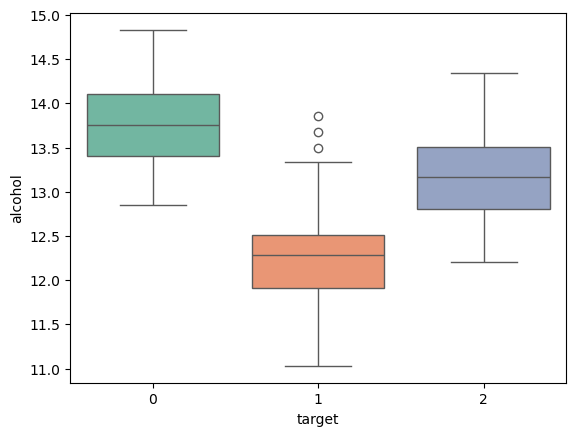

In [47]:
sns.boxplot(x = 'target', y = 'alcohol', data = df, palette = 'Set2')

In [48]:
t0 = df[df['target'] == 0]['alcohol']
t1 = df[df['target'] == 1]['alcohol']
t2 = df[df['target'] == 2]['alcohol']

In [49]:
shapiro(t0)

ShapiroResult(statistic=0.9808939732940862, pvalue=0.47906805750231335)

In [50]:
shapiro(t1)

ShapiroResult(statistic=0.9720515958359174, pvalue=0.11396072209600777)

In [51]:
shapiro(t2)
# 정규성 만족

ShapiroResult(statistic=0.9814676041222525, pvalue=0.6408387007191562)

In [52]:
levene(t0, t1, t2)
# 등분산 만족

LeveneResult(statistic=0.5997889815519192, pvalue=0.5500519055097621)

In [56]:
model = ols('alcohol ~ target', data=df).fit()
anova_lm(model, typ = 2, robust = 'hc3')

# p-value < 0.05 → 유의미하다 → 귀무가설(H₀) 기각 → target 값에 따라 종속변수 평균이 적어도 하나 이상 유의미하게 차이가 있다.

,sum_sq,df,F,PR(>F)
target,15.396164,1.0,26.033286,8.634459e-07
Residual,104.086935,176.0,NaN,NaN


In [57]:
# 예제 2
# tips 데이터를 사용하여 요일(day)에 따라 팁(tip) 평균이 다른지 box plot으로 시각화하여 비교하고,
# 통계적으로 유의미한 차이가 있는지 ANOVA test를 통해 검정하시오.

tips = sns.load_dataset('tips')
tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Axes: xlabel='day', ylabel='tip'>

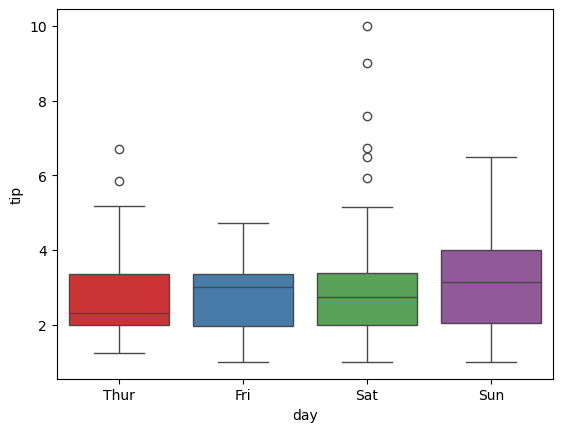

In [58]:
sns.boxplot(x = 'day', y = 'tip', data=tips, palette = 'Set1')

In [60]:
thur = tips[tips['day'] == 'Thur']['tip']
fri = tips[tips['day'] == 'Fri']['tip']
sat = tips[tips['day'] == 'Sat']['tip']
sun = tips[tips['day'] == 'Sun']['tip']

In [63]:
print(shapiro(thur))
print(shapiro(fri))
print(shapiro(sat))
print(shapiro(sun))
# 정규성 만족

ShapiroResult(statistic=0.8752102990749261, pvalue=1.3876520528918699e-05)
ShapiroResult(statistic=0.973836248851136, pvalue=0.8496941690730639)
ShapiroResult(statistic=0.8243012076973782, pvalue=8.842291063390011e-09)
ShapiroResult(statistic=0.9631152621327175, pvalue=0.02632980475101127)


In [64]:
levene(thur, fri, sat, sun)
# 등분산 만족

LeveneResult(statistic=0.5519761112415968, pvalue=0.6472822314837223)

In [65]:
model = ols('tip ~ day', data = tips).fit()
anova_lm(model, typ = 2, robust = 'hc3')

# p-value > 0.05 → 유의미하지 않다 → H₀ 기각 불가 → 요일(day)에 따라 종속변수의 평균 차이는 통계적으로 유의미하지 않다.

,sum_sq,df,F,PR(>F)
day,12.303589,3.0,2.160009,0.093389
Residual,455.686604,240.0,NaN,NaN
